![Imgur](https://i.imgur.com/5pXzCIu.png)

# Data Science va Sun'iy Intellekt Praktikum

## 5-MODUL. Machine Learning.

### Amaliyot. Simple Linear Regression

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [14]:
df = pd.read_csv('https://raw.githubusercontent.com/anvarnarz/praktikum_datasets/main/reklama_sales.csv')
df.head(20)

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
5,8.7,48.9,75.0,7.2
6,57.5,32.8,23.5,11.8
7,120.2,19.6,11.6,13.2
8,8.6,2.1,1.0,4.8
9,199.8,2.6,21.2,15.6


Yuqoridagi jadvalda MohirDev MChJ tomonidan turli OAV larda (`TV`, `Radio`, `Newspaper`) berilgan reklamalar soni va mos keluvchi savdolar (`Sales`) berilgan.

Sizning vazifangiz:
1. Aynan qaysi turdagi OAVda reklama berish savdo o'sishiga ta'sir qiladi aniqlash
2. Topilgan bog'liqlik asosida Simple Linear Regression algorithmi yordamida bashorat modelini qurish.

Ushbu amaliyotda sizning vazifangiz berilgan dataset yordamida Simple Linear Regression model yaratish:
- CRISP-DM metodologiyasiga amal qiling!
- Simple linear regression qo'llash uchun 1 ta ustunni tanlab oling.

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [21]:
df.corrwith(df['Sales']).sort_values(ascending=False) # TV ning tasiri savdoga demak kop ekan

,0
Sales,1.000000
TV,0.901208
Radio,0.349631
Newspaper,0.157960


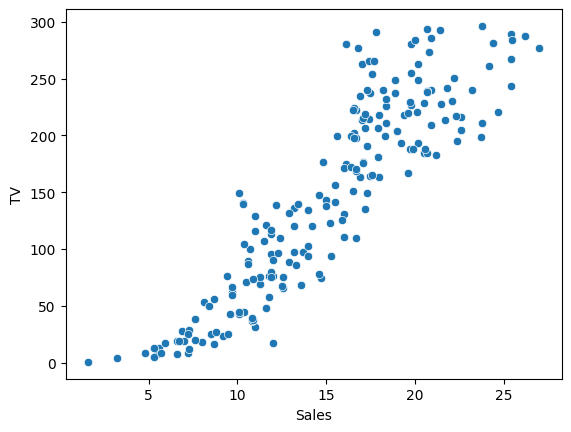

In [16]:
sns.scatterplot(data = df, x = 'Sales', y = 'TV')
plt.show()

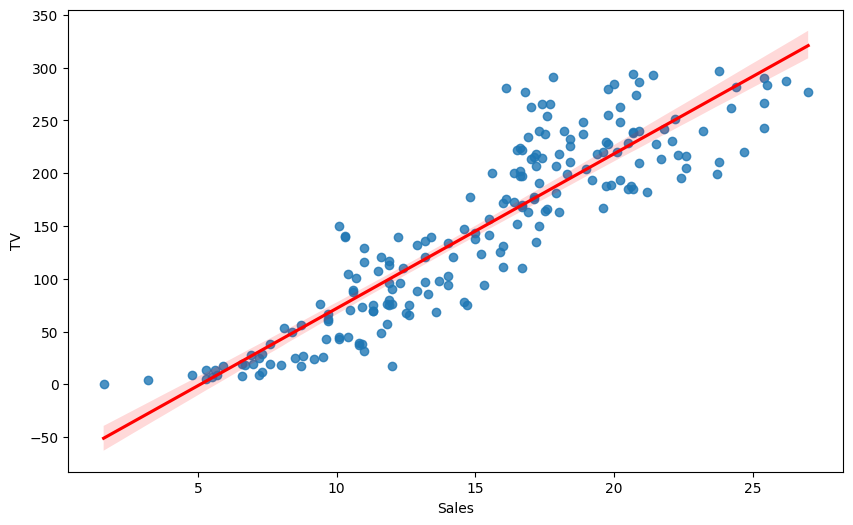

In [17]:
plt.figure(figsize = (10,6))
sns.regplot(data = df, x = 'Sales', y = 'TV', line_kws={'color':'red'})
plt.show()

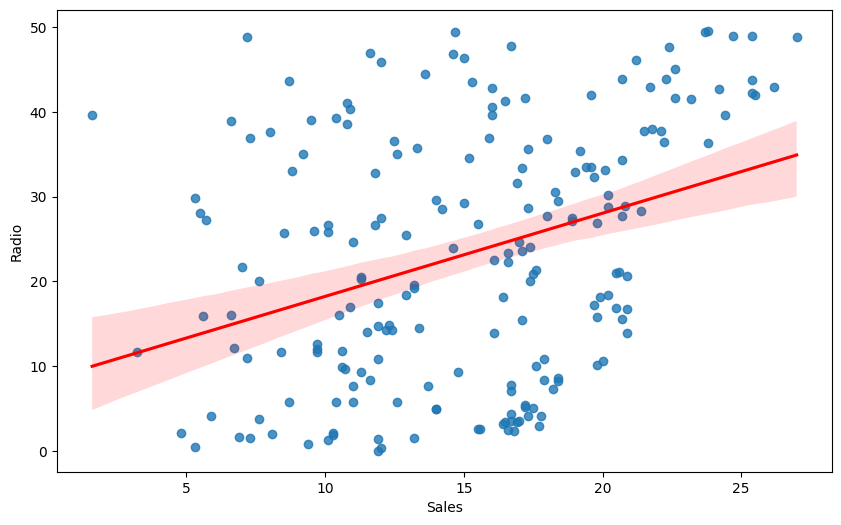

In [18]:
plt.figure(figsize = (10,6))
sns.regplot(data = df, x = 'Sales', y = 'Radio', line_kws={'color':'red'})
plt.show()

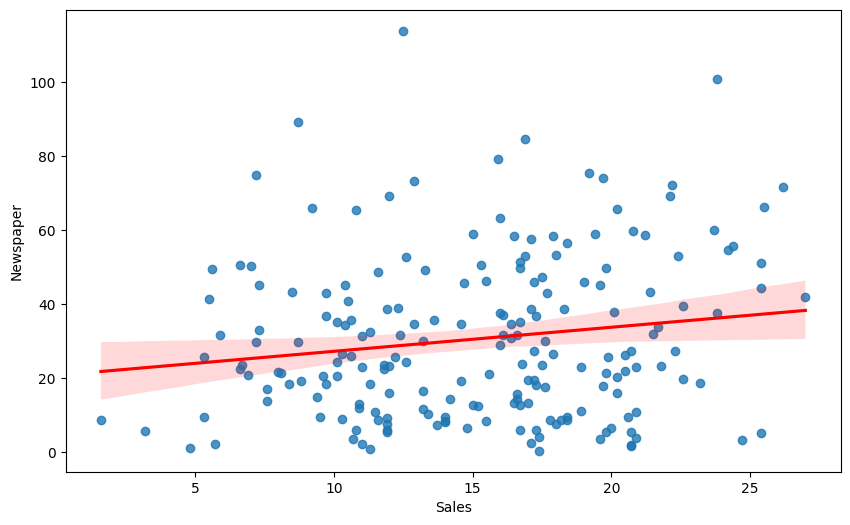

In [19]:
plt.figure(figsize = (10,6))
sns.regplot(data = df, x = 'Sales', y = 'Newspaper', line_kws={'color':'red'})
plt.show()

Train and test split

In [22]:
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(df, test_size = 0.1, random_state = 42)


In [23]:
from sklearn.linear_model import LinearRegression
LR_model = LinearRegression()

x_train = np.asanyarray(train_set[['TV']])
y_train = np.asanyarray(train_set[['Sales']])

LR_model.fit(x_train, y_train)

LinearRegression()

In [26]:
theta1 = LR_model.coef_[0][0]
theta0 = LR_model.intercept_[0]
print(f"{theta1=}")
print(f"{theta0=}")

theta1=np.float64(0.05513263076693964)
theta0=np.float64(7.044916461655207)


testing

In [27]:
x_test = np.asanyarray(test_set[['TV']])
y_test = np.asanyarray(test_set[['Sales']])

y_predict = LR_model.predict(x_test)

#RMSE and MAE

In [28]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error
rmse = root_mean_squared_error(y_test, y_predict)
mae = mean_absolute_error(y_test, y_predict)
print(f"RMSE = {rmse}")
print(f"MAE = {mae}")

RMSE = 2.5103822386472214
MAE = 2.037955356968121


#With Full dataset

In [29]:
x = np.asanyarray(df[['TV']])
y = np.asanyarray(df[['Sales']])
model = LR_model.fit(x,y)

In [30]:
model


LinearRegression()

In [31]:
#test
data = df.sample(10, random_state = 42)
xtest = data[['TV']].to_numpy()
ytest = data[['Sales']].to_numpy()

ypredict = model.predict(xtest)

In [32]:
ypredict, ytest

(array([[16.03221851],
        [17.81263764],
        [23.22045276],
        [ 7.6237593 ],
        [19.19371042],
        [11.14022575],
        [18.99958373],
        [ 9.74806001],
        [19.31018644],
        [16.6867028 ]]),
 array([[16.9],
        [22.4],
        [21.4],
        [ 7.3],
        [24.7],
        [12.6],
        [22.3],
        [ 8.4],
        [16.5],
        [16.1]]))

In [33]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error
rmse = root_mean_squared_error(ytest, ypredict)
mae = mean_absolute_error(ytest, ypredict)
print(f"RMSE = {rmse}")
print(f"MAE = {mae}")

RMSE = 2.803878628690741
MAE = 2.26107852682164
